# Ispitivanje faktora koji utiču na prihvatanje korišćenja sistema baziranih na veštačkoj inteligenciji u zdravstvu  

**Glavno istraživačko pitanje:** Koji faktori su povezani sa prihvatanjem korišćenja sistema baziranih na veštačkoj inteligenciji u zdravstvu i u kojoj meri se na osnovu njih može objasniti i predvideti nivo prihvatanja?

## 0. Instalacija potrebnih biblioteka

In [2]:
from pathlib import Path
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE=42
pd.set_option("display.max_columns",120)
pd.set_option("display.max_rows",300)
pd.set_option("display.float_format",lambda x:f"{x:.3f}")

# FAZA I Učitavanje i kontrola kvaliteta podataka

In [3]:
FILE_PATH=Path("C:/Users/Lenovo/OneDrive - Fakultet organizacionih nauka/Desktop/Diplomski/Rezultati istrazivanja.xlsx")

df=pd.read_excel(FILE_PATH,sheet_name=0)
df.columns=(df.columns.astype(str).str.strip().str.replace("\n","",regex=False))
print(f"Broj ispitanika: {df.shape[0]}")
print(f"Broj početnih promenljivih: {df.shape[1]}")
display(df.head())

Broj ispitanika: 121
Broj početnih promenljivih: 43


,Pol,GodinaRodjenja,Obrazovanje,Iskustvo_u_zdravstvu,Iskustvo_u_IT,Koristi_ChatGPT,Koristi_Gemini,Koristi_Claude,Koristi_Copilot,Ucestalost_AI,Namena_AI,AI_Ishrana,AI_Lekovi,Provera_Kod_Lekara,AI_Koza,AI_KrvnaSlika,AI_Laboratorija,AI_Rendgen,AI_Ultrazvuk,AI_RazumevanjeNalaza,AI_Administracija,AI_Anamneza,AI_Dijagnoza,AI_Poverenje_Lekar,AI_Efikasnost,AI_Komunikacija,AI_Prihvatanje_Ustanove,Privatnost_Podataka,Transparentnost_AI,Poverenje_Ustanova_AI,Napredna_Ustanova,Deljenje_Podataka,Potreba_BrzPristup,Potreba_PosvecenostLekara,Potreba_JasnaObjasnjenja,Digitalni_Nalazi,App_ZdravstveniKarton,App_Podsetnik,App_PracenjeSimptoma,Dnevnik_PomocLekaru,App_Komunikacija,Grafikoni_Istorija,Digitalna_Briga
0,Muški,1968,Srednja škola,Ne,Ne,Da,Da,Ne,Ne,Svakodnevno,"Učenje i objašnjavanje gradiva, Pretraga i saž...",5,5,5,5,5,5,5,5,5,5,3,3,5,5,3,5,5,5,5,5,4,5,5,5,4,4,5,5,5,5,4,4
1,Ženski,2003,Osnovne akademske studije,Ne,Da,Da,Da,Da,Da,Svakodnevno,"Učenje i objašnjavanje gradiva, Pretraga i saž...",5,3,4,3,4,5,2,2,5,5,5,4,5,5,5,5,5,5,3,4,3,5,5,5,5,5,5,5,4,5,4,5
2,Ženski,1968,Master (Magistarske) akademske studije,Ne,Ne,Da,Ne,Ne,Ne,Nekoliko puta nedeljno,"Pretraga i sažimanje informacija,",2,3,4,3,1,1,2,2,3,3,3,2,2,2,3,2,3,3,3,3,3,5,5,5,4,5,5,4,3,4,4,4
3,Muški,2002,Osnovne akademske studije,Ne,Da,Da,Da,Da,Ne,Nekoliko puta nedeljno,"Učenje i objašnjavanje gradiva, Rešavanje svak...",4,4,4,3,4,4,3,3,4,5,3,4,4,5,4,4,4,4,4,4,4,4,4,5,4,5,5,5,5,5,5,4
4,Ženski,1970,Master (Magistarske) akademske studije,Da,Ne,Da,Ne,Ne,Ne,Nekoliko puta nedeljno,"Pretraga i sažimanje informacija, Zdravstvena ...",4,4,5,2,2,4,3,4,4,4,5,4,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5


In [4]:
pregled_kvaliteta=pd.DataFrame({"Tip podatka":df.dtypes.astype(str),"Popunjeno":df.notna().sum(),"Nedostaje":df.isna().sum(),"Jedinstvene vrednosti":df.nunique(dropna=True)})
display(pregled_kvaliteta)

print("Ukupan broj nedostajućih vrednosti:",int(df.isna().sum().sum()))
print("Broj potpuno dupliranih redova:",int(df.duplicated().sum()))
print("Duplirani nazivi kolona:",df.columns[df.columns.duplicated()].tolist())

,Tip podatka,Popunjeno,Nedostaje,Jedinstvene vrednosti
Pol,object,121,0,2
GodinaRodjenja,int64,121,0,39
Obrazovanje,object,121,0,4
Iskustvo_u_zdravstvu,object,121,0,2
Iskustvo_u_IT,object,121,0,2
Koristi_ChatGPT,object,121,0,2
Koristi_Gemini,object,121,0,2
Koristi_Claude,object,121,0,2
Koristi_Copilot,object,121,0,2
Ucestalost_AI,object,121,0,5


Ukupan broj nedostajućih vrednosti: 0
Broj potpuno dupliranih redova: 0
Duplirani nazivi kolona: []


In [5]:
df["GodinaRodjenja"]=pd.to_numeric(df["GodinaRodjenja"],errors="coerce")

df["Starost"]=2026-df["GodinaRodjenja"]

nelogicne=df.loc[(df["GodinaRodjenja"]<1930)|(df["GodinaRodjenja"]>2010)|df["GodinaRodjenja"].isna(),["GodinaRodjenja","Starost"]]

display(df["Starost"].describe())

print("Sve godine rođenja deluju ispravno." if nelogicne.empty else "Proveriti sledeće godine rođenja:")
if not nelogicne.empty: display(nelogicne)

count         121.000
mean      -157932.744
std       1736352.901
min     -19099956.000
25%            22.000
50%            24.000
75%            46.000
max          2008.000
Name: Starost, dtype: float64

Proveriti sledeće godine rođenja:


,GodinaRodjenja,Starost
29,42,1984
71,19721,-17695
83,18,2008
102,19101982,-19099956


In [6]:
likert_kolone=["AI_Ishrana","AI_Lekovi","Provera_Kod_Lekara","AI_Koza","AI_KrvnaSlika","AI_Laboratorija","AI_Rendgen","AI_Ultrazvuk","AI_RazumevanjeNalaza","AI_Administracija","AI_Anamneza","AI_Dijagnoza","AI_Poverenje_Lekar","AI_Efikasnost","AI_Komunikacija","AI_Prihvatanje_Ustanove","Privatnost_Podataka","Transparentnost_AI","Poverenje_Ustanova_AI","Napredna_Ustanova","Deljenje_Podataka","Potreba_BrzPristup","Potreba_PosvecenostLekara","Potreba_JasnaObjasnjenja","Digitalni_Nalazi","App_ZdravstveniKarton","App_Podsetnik","App_PracenjeSimptoma","Dnevnik_PomocLekaru","App_Komunikacija","Grafikoni_Istorija","Digitalna_Briga"]
nedostaju=[c for c in likert_kolone if c not in df.columns]

if nedostaju: raise ValueError(f"Nedostaju Likert kolone: {nedostaju}")
df[likert_kolone]=df[likert_kolone].apply(pd.to_numeric,errors="coerce")
neispravne={}

for c in likert_kolone:
    vals=sorted(df.loc[df[c].notna() & ~df[c].between(1,5),c].unique())
    if vals: neispravne[c]=vals

print("Neispravne Likert vrednosti:",neispravne if neispravne else "Nema — sve su u opsegu 1–5.")

Neispravne Likert vrednosti: Nema — sve su u opsegu 1–5.


# FAZA II Kodiranje pomoćnih promenljivih

In [7]:
map_da_ne={"Da":1,"Ne":0}

for c in ["Iskustvo_u_zdravstvu","Iskustvo_u_IT","Koristi_ChatGPT","Koristi_Gemini","Koristi_Claude","Koristi_Copilot"]:
    if c in df.columns: df[f"{c}_bin"]=df[c].map(map_da_ne)

ucestalost_map={"Nikada":1,"Retko":2,"Nekoliko puta mesečno":3,"Nekoliko puta nedeljno":4,"Svakodnevno":5}

df["Ucestalost_AI_num"]=df["Ucestalost_AI"].map(ucestalost_map)

alat_bin=["Koristi_ChatGPT_bin","Koristi_Gemini_bin","Koristi_Claude_bin","Koristi_Copilot_bin"]

df["Broj_AI_alata"]=df[alat_bin].sum(axis=1)

df["Koristi_AI_za_zdravstvo"]=(df["Namena_AI"].fillna("").str.contains("Zdravstvena i medicinska pitanja",case=False,regex=False).astype(int))

display(df[["Starost","Ucestalost_AI_num","Broj_AI_alata","Koristi_AI_za_zdravstvo"]].head())

,Starost,Ucestalost_AI_num,Broj_AI_alata,Koristi_AI_za_zdravstvo
0,58,5,2,1
1,23,5,4,0
2,58,4,1,0
3,24,4,3,1
4,56,4,1,1


# FAZA III Teorijsko definisanje tematskih skorova

In [8]:
stavke_prihvatanje=["AI_Ishrana","AI_Lekovi","AI_Koza","AI_KrvnaSlika","AI_Laboratorija","AI_Rendgen","AI_Ultrazvuk","AI_Dijagnoza","AI_Prihvatanje_Ustanove"]
stavke_korisnost=["AI_RazumevanjeNalaza","AI_Administracija","AI_Efikasnost","AI_Komunikacija"]
stavke_nadzor_original=["Provera_Kod_Lekara","AI_Anamneza","AI_Poverenje_Lekar"]
stavke_nadzor_final=["AI_Anamneza","AI_Poverenje_Lekar"]
stavke_privatnost_original=["Privatnost_Podataka","Transparentnost_AI","Deljenje_Podataka"]
stavke_ustanova=["Poverenje_Ustanova_AI","Napredna_Ustanova"]

teorijska_struktura=pd.DataFrame([
["Prihvatanje AI",len(stavke_prihvatanje),", ".join(stavke_prihvatanje)],
["Korisnost AI",len(stavke_korisnost),", ".join(stavke_korisnost)],
["Nadzor — original",len(stavke_nadzor_original),", ".join(stavke_nadzor_original)],
["Nadzor — final",len(stavke_nadzor_final),", ".join(stavke_nadzor_final)],
["Privatnost + transparentnost — kandidat",len(stavke_privatnost_original),", ".join(stavke_privatnost_original)],
["Percepcija ustanove",len(stavke_ustanova),", ".join(stavke_ustanova)]],columns=["Tematski skor","Broj stavki","Stavke"])

display(teorijska_struktura)

,Tematski skor,Broj stavki,Stavke
0,Prihvatanje AI,9,"AI_Ishrana, AI_Lekovi, AI_Koza, AI_KrvnaSlika,..."
1,Korisnost AI,4,"AI_RazumevanjeNalaza, AI_Administracija, AI_Ef..."
2,Nadzor — original,3,"Provera_Kod_Lekara, AI_Anamneza, AI_Poverenje_..."
3,Nadzor — final,2,"AI_Anamneza, AI_Poverenje_Lekar"
4,Privatnost + transparentnost — kandidat,3,"Privatnost_Podataka, Transparentnost_AI, Delje..."
5,Percepcija ustanove,2,"Poverenje_Ustanova_AI, Napredna_Ustanova"


# FAZA IV Detaljna provera pouzdanosti tematskih skorova

In [9]:
def cronbach_alpha(data):
    x=data.dropna().astype(float); k=x.shape[1]
    if k<2: return np.nan
    total_var=x.sum(axis=1).var(ddof=1)
    if total_var==0: return np.nan
    return (k/(k-1))*(1-x.var(axis=0,ddof=1).sum()/total_var)

def scale_diagnostics(data,items,name):
    x=data[items].dropna().astype(float); rows=[]
    alpha=cronbach_alpha(x)
    for item in items:
        others=[i for i in items if i!=item]
        rest=x[others].mean(axis=1) if others else pd.Series(index=x.index,dtype=float)
        r=x[item].corr(rest) if others else np.nan
        a_del=cronbach_alpha(x[others]) if len(others)>=2 else np.nan
        rows.append({"Skala":name,"Stavka":item,"Korelacija stavka–ostatak":r,"Alpha ako se izbaci":a_del})
    return alpha,pd.DataFrame(rows)

candidate_scales={"Prihvatanje AI":stavke_prihvatanje,"Korisnost AI":stavke_korisnost,"Nadzor — original":stavke_nadzor_original,"Nadzor — final 2 stavke":stavke_nadzor_final,"Privatnost + transparentnost — original":stavke_privatnost_original,"Percepcija ustanove":stavke_ustanova}
summary=[]; details=[]
for name,items in candidate_scales.items():
    a,d=scale_diagnostics(df,items,name); summary.append({"Tematski skor":name,"Broj stavki":len(items),"Cronbach alpha":a}); details.append(d)
pouzdanost=pd.DataFrame(summary); detalji_pouzdanosti=pd.concat(details,ignore_index=True)
display(pouzdanost.round(3)); display(detalji_pouzdanosti.round(3))

,Tematski skor,Broj stavki,Cronbach alpha
0,Prihvatanje AI,9,0.906
1,Korisnost AI,4,0.860
2,Nadzor — original,3,0.562
3,Nadzor — final 2 stavke,2,0.746
4,Privatnost + transparentnost — original,3,0.176
5,Percepcija ustanove,2,0.789


,Skala,Stavka,Korelacija stavka–ostatak,Alpha ako se izbaci
0,Prihvatanje AI,AI_Ishrana,0.567,0.903
1,Prihvatanje AI,AI_Lekovi,0.453,0.911
2,Prihvatanje AI,AI_Koza,0.579,0.903
3,Prihvatanje AI,AI_KrvnaSlika,0.775,0.888
4,Prihvatanje AI,AI_Laboratorija,0.805,0.886
5,Prihvatanje AI,AI_Rendgen,0.817,0.885
6,Prihvatanje AI,AI_Ultrazvuk,0.823,0.884
7,Prihvatanje AI,AI_Dijagnoza,0.581,0.902
8,Prihvatanje AI,AI_Prihvatanje_Ustanove,0.722,0.892
9,Korisnost AI,AI_RazumevanjeNalaza,0.571,0.871


## Korelacije stavki tematskih skorova

In [10]:
for name,items in candidate_scales.items():
    print("\n"+"="*80); print(name); display(df[items].corr(method="spearman").round(3))


Prihvatanje AI


,AI_Ishrana,AI_Lekovi,AI_Koza,AI_KrvnaSlika,AI_Laboratorija,AI_Rendgen,AI_Ultrazvuk,AI_Dijagnoza,AI_Prihvatanje_Ustanove
AI_Ishrana,1.000,0.517,0.329,0.440,0.450,0.454,0.452,0.409,0.535
AI_Lekovi,0.517,1.000,0.318,0.391,0.393,0.297,0.329,0.287,0.426
AI_Koza,0.329,0.318,1.000,0.649,0.581,0.553,0.554,0.243,0.335
AI_KrvnaSlika,0.440,0.391,0.649,1.000,0.870,0.697,0.705,0.381,0.544
AI_Laboratorija,0.450,0.393,0.581,0.870,1.000,0.737,0.725,0.479,0.621
AI_Rendgen,0.454,0.297,0.553,0.697,0.737,1.000,0.971,0.506,0.623
AI_Ultrazvuk,0.452,0.329,0.554,0.705,0.725,0.971,1.000,0.514,0.615
AI_Dijagnoza,0.409,0.287,0.243,0.381,0.479,0.506,0.514,1.000,0.716
AI_Prihvatanje_Ustanove,0.535,0.426,0.335,0.544,0.621,0.623,0.615,0.716,1.000



Korisnost AI


,AI_RazumevanjeNalaza,AI_Administracija,AI_Efikasnost,AI_Komunikacija
AI_RazumevanjeNalaza,1.000,0.537,0.561,0.459
AI_Administracija,0.537,1.000,0.756,0.577
AI_Efikasnost,0.561,0.756,1.000,0.700
AI_Komunikacija,0.459,0.577,0.700,1.000



Nadzor — original


...

,AI_Anamneza,AI_Poverenje_Lekar
AI_Anamneza,1.000,0.614
AI_Poverenje_Lekar,0.614,1.000



Privatnost + transparentnost — original


,Privatnost_Podataka,Transparentnost_AI,Deljenje_Podataka
Privatnost_Podataka,1.000,0.445,0.073
Transparentnost_AI,0.445,1.000,-0.038
Deljenje_Podataka,0.073,-0.038,1.000



Percepcija ustanove


,Poverenje_Ustanova_AI,Napredna_Ustanova
Poverenje_Ustanova_AI,1.000,0.622
Napredna_Ustanova,0.622,1.000


## Provera pouzdanosti novih tematskih skorova

In [10]:
def all_subset_alphas(data,items,min_items=2):
    out=[]
    for k in range(min_items,len(items)+1):
        for subset in combinations(items,k):
            out.append({"Broj stavki":k,"Stavke":", ".join(subset),"Cronbach alpha":cronbach_alpha(data[list(subset)])})
    return pd.DataFrame(out).sort_values("Cronbach alpha",ascending=False)

print("NADZOR"); display(all_subset_alphas(df,stavke_nadzor_original).round(3))
print("PRIVATNOST / TRANSPARENTNOST / DELJENJE"); display(all_subset_alphas(df,stavke_privatnost_original).round(3))

NADZOR


,Broj stavki,Stavke,Cronbach alpha
2,2,"AI_Anamneza, AI_Poverenje_Lekar",0.746
3,3,"Provera_Kod_Lekara, AI_Anamneza, AI_Poverenje_...",0.562
1,2,"Provera_Kod_Lekara, AI_Poverenje_Lekar",0.345
0,2,"Provera_Kod_Lekara, AI_Anamneza",0.173


PRIVATNOST / TRANSPARENTNOST / DELJENJE


,Broj stavki,Stavke,Cronbach alpha
0,2,"Privatnost_Podataka, Transparentnost_AI",0.402
3,3,"Privatnost_Podataka, Transparentnost_AI, Delje...",0.176
1,2,"Privatnost_Podataka, Deljenje_Podataka",0.133
2,2,"Transparentnost_AI, Deljenje_Podataka",-0.078


## Konačan izbor tematskih skorova

In [11]:
finalne_skale={"Skor_Prihvatanje":stavke_prihvatanje,"Skor_Korisnost":stavke_korisnost,"Skor_Nadzor":stavke_nadzor_final,"Skor_Ustanova":stavke_ustanova}
final_reliability=[]

for score,items in finalne_skale.items():
    a=cronbach_alpha(df[items]); final_reliability.append({"Skor":score,"Broj stavki":len(items),"Cronbach alpha":a,"Status":"zadovoljavajuće" if a>=.70 else "zahteva oprez"})
final_reliability=pd.DataFrame(final_reliability); display(final_reliability.round(3))

print("Sve finalne višestavkovne skale imaju Cronbach α ≥ 0,70." if (final_reliability["Cronbach alpha"]>=.70).all() else "PAŽNJA: najmanje jedna finalna skala je ispod 0,70 — proveriti pre interpretacije.")

,Skor,Broj stavki,Cronbach alpha,Status
0,Skor_Prihvatanje,9,0.906,zadovoljavajuće
1,Skor_Korisnost,4,0.860,zadovoljavajuće
2,Skor_Nadzor,2,0.746,zadovoljavajuće
3,Skor_Ustanova,2,0.789,zadovoljavajuće


Sve finalne višestavkovne skale imaju Cronbach α ≥ 0,70.


# FAZA V Formiranje i detaljan opis finalnih tematskih skorova

In [12]:
for score,items in finalne_skale.items(): df[score]=df[items].mean(axis=1)
skor_kolone=list(finalne_skale.keys())
opis_skorova=df[skor_kolone].agg(["count","mean","std","median","min","max"]).T
opis_skorova.columns=["N","Prosek","Standardna devijacija","Medijana","Minimum","Maksimum"]
display(opis_skorova.round(3))

,N,Prosek,Standardna devijacija,Medijana,Minimum,Maksimum
Skor_Prihvatanje,121.000,3.143,1.038,3.111,1.000,5.000
Skor_Korisnost,121.000,3.483,1.031,3.500,1.000,5.000
Skor_Nadzor,121.000,3.525,1.183,3.500,1.000,5.000
Skor_Ustanova,121.000,3.541,1.134,3.500,1.000,5.000


In [13]:
for score,items in finalne_skale.items():
    print("\n"+"="*90); print(score); print(f"Cronbach α = {cronbach_alpha(df[items]):.3f}")
    tab=df[items].agg(["count","mean","std","median","min","max"]).T; tab.columns=["N","Prosek","SD","Medijana","Minimum","Maksimum"]; display(tab.round(3))


Skor_Prihvatanje
Cronbach α = 0.906


,N,Prosek,SD,Medijana,Minimum,Maksimum
AI_Ishrana,121.000,3.405,1.144,3.000,1.000,5.000
AI_Lekovi,121.000,3.124,1.320,3.000,1.000,5.000
AI_Koza,121.000,3.364,1.384,4.000,1.000,5.000
AI_KrvnaSlika,121.000,3.388,1.399,4.000,1.000,5.000
AI_Laboratorija,121.000,3.446,1.402,4.000,1.000,5.000
AI_Rendgen,121.000,2.736,1.510,3.000,1.000,5.000
AI_Ultrazvuk,121.000,2.744,1.486,3.000,1.000,5.000
AI_Dijagnoza,121.000,2.851,1.333,3.000,1.000,5.000
AI_Prihvatanje_Ustanove,121.000,3.231,1.353,3.000,1.000,5.000



Skor_Korisnost
Cronbach α = 0.860


,N,Prosek,SD,Medijana,Minimum,Maksimum
AI_RazumevanjeNalaza,121.000,3.628,1.081,4.000,1.000,5.000
AI_Administracija,121.000,3.430,1.270,3.000,1.000,5.000
AI_Efikasnost,121.000,3.727,1.225,4.000,1.000,5.000
AI_Komunikacija,121.000,3.149,1.327,3.000,1.000,5.000



Skor_Nadzor
Cronbach α = 0.746


,N,Prosek,SD,Medijana,Minimum,Maksimum
AI_Anamneza,121.000,3.083,1.388,3.000,1.000,5.000
AI_Poverenje_Lekar,121.000,3.967,1.258,4.000,1.000,5.000



Skor_Ustanova
Cronbach α = 0.789


,N,Prosek,SD,Medijana,Minimum,Maksimum
Poverenje_Ustanova_AI,121.000,3.587,1.256,4.000,1.000,5.000
Napredna_Ustanova,121.000,3.496,1.239,4.000,1.000,5.000


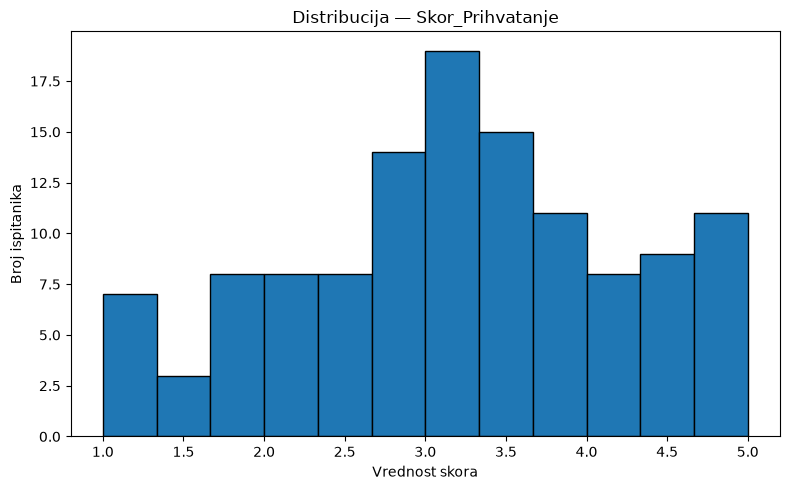

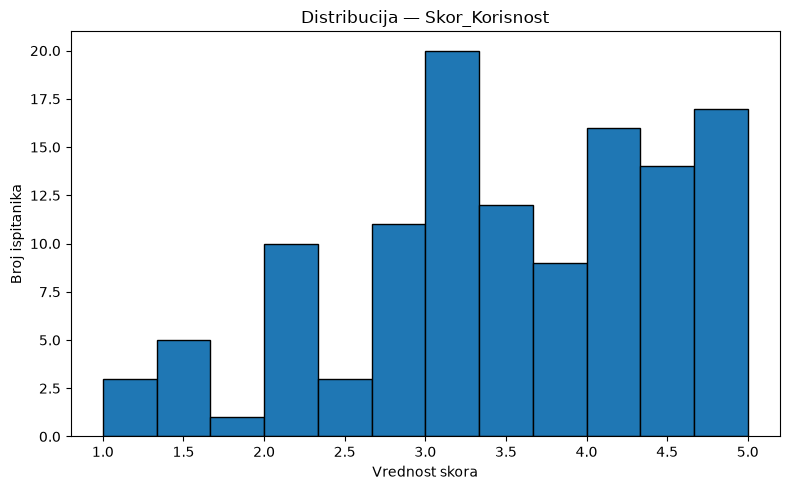

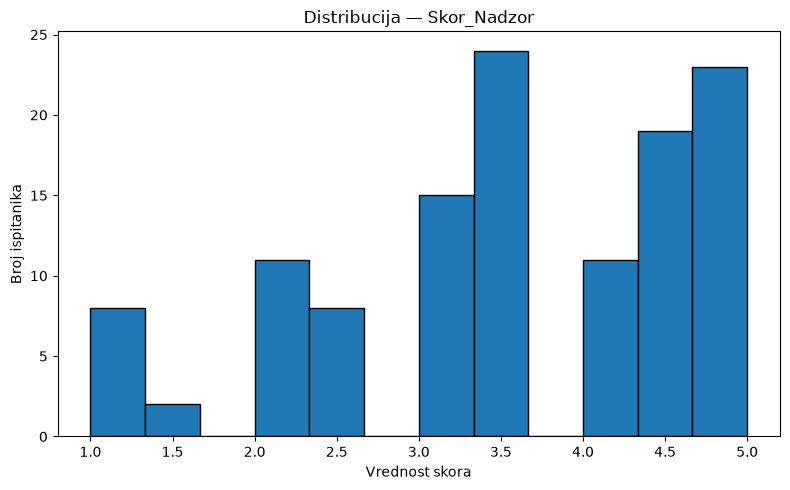

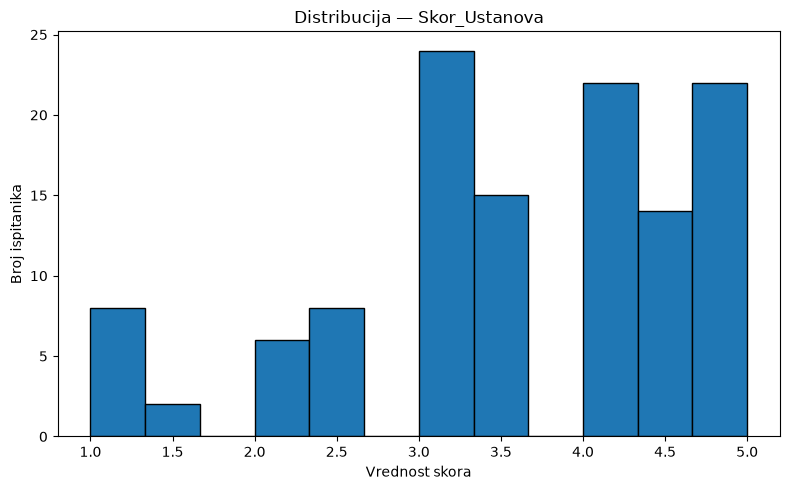

In [14]:
for score in skor_kolone:
    plt.figure(figsize=(8,5)); plt.hist(df[score].dropna(),bins=12,edgecolor="black"); plt.xlabel("Vrednost skora"); plt.ylabel("Broj ispitanika"); plt.title(f"Distribucija — {score}"); plt.tight_layout(); plt.show()

,Prosek
Skor_Prihvatanje,3.143
Deljenje_Podataka,3.281
Skor_Korisnost,3.483
Skor_Nadzor,3.525
Skor_Ustanova,3.541
Privatnost_Podataka,4.438
Transparentnost_AI,4.769


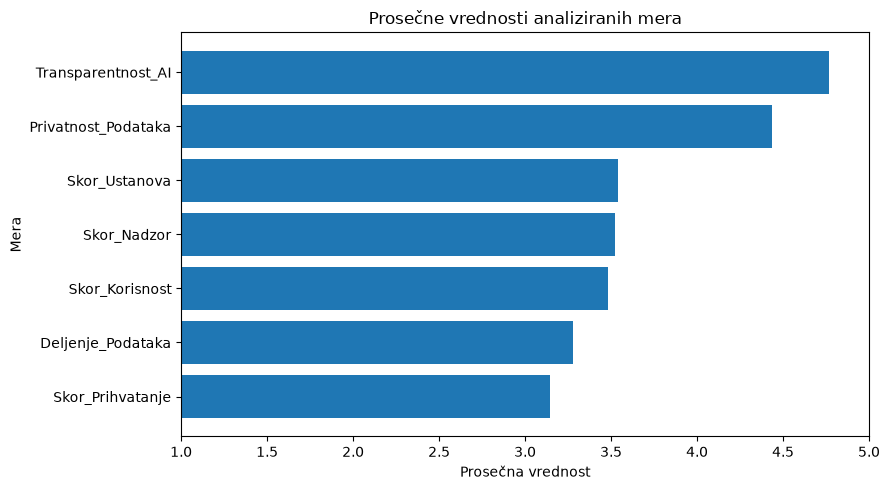

In [15]:
analiticke_mere=skor_kolone+["Privatnost_Podataka","Transparentnost_AI","Deljenje_Podataka"]
proseci=df[analiticke_mere].mean().sort_values(); display(pd.DataFrame({"Prosek":proseci}).round(3))
plt.figure(figsize=(9,5)); plt.barh(proseci.index,proseci.values); plt.xlim(1,5); plt.xlabel("Prosečna vrednost"); plt.ylabel("Mera"); plt.title("Prosečne vrednosti analiziranih mera"); plt.tight_layout(); plt.show()

# FAZA VI Korelaciona analiza

,Skor_Prihvatanje,Skor_Korisnost,Skor_Nadzor,Skor_Ustanova,Privatnost_Podataka,Transparentnost_AI,Deljenje_Podataka
Skor_Prihvatanje,1.000,0.802,0.680,0.615,0.149,-0.015,0.576
Skor_Korisnost,0.802,1.000,0.784,0.748,0.221,-0.051,0.563
Skor_Nadzor,0.680,0.784,1.000,0.635,0.209,0.031,0.518
Skor_Ustanova,0.615,0.748,0.635,1.000,0.237,0.025,0.576
Privatnost_Podataka,0.149,0.221,0.209,0.237,1.000,0.445,0.073
Transparentnost_AI,-0.015,-0.051,0.031,0.025,0.445,1.000,-0.038
Deljenje_Podataka,0.576,0.563,0.518,0.576,0.073,-0.038,1.000


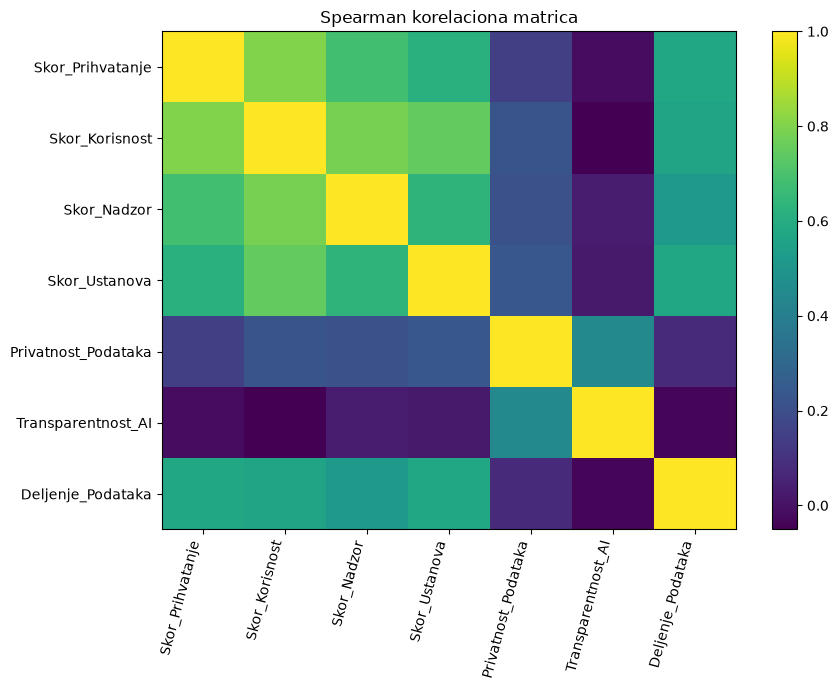

In [16]:
corr_matrix=df[analiticke_mere].corr(method="spearman"); display(corr_matrix.round(3))
fig,ax=plt.subplots(figsize=(9,7)); im=ax.imshow(corr_matrix.values,aspect="auto"); ax.set_xticks(range(len(corr_matrix.columns))); ax.set_yticks(range(len(corr_matrix.index))); ax.set_xticklabels(corr_matrix.columns,rotation=75,ha="right"); ax.set_yticklabels(corr_matrix.index); plt.colorbar(im); plt.title("Spearman korelaciona matrica"); plt.tight_layout(); plt.show()

In [17]:
prediktori_korelacije=["Skor_Korisnost","Skor_Nadzor","Skor_Ustanova","Privatnost_Podataka","Transparentnost_AI","Deljenje_Podataka","Starost","Iskustvo_u_zdravstvu_bin","Iskustvo_u_IT_bin","Ucestalost_AI_num","Broj_AI_alata","Koristi_AI_za_zdravstvo"]
rez=[]

for p in prediktori_korelacije:
    tmp=df[[p,"Skor_Prihvatanje"]].dropna(); rho,pv=spearmanr(tmp[p],tmp["Skor_Prihvatanje"]); rez.append([p,rho,pv,len(tmp)])
korelacije_prihvatanje=pd.DataFrame(rez,columns=["Prediktor","Spearman rho","p vrednost","N"]); korelacije_prihvatanje["p korigovano"]=multipletests(korelacije_prihvatanje["p vrednost"],method="fdr_bh")[1]; korelacije_prihvatanje["Značajno posle korekcije"]=korelacije_prihvatanje["p korigovano"]<.05
display(korelacije_prihvatanje.sort_values("Spearman rho",ascending=False).round(4))

,Prediktor,Spearman rho,p vrednost,N,p korigovano,Značajno posle korekcije
0,Skor_Korisnost,0.802,0.000,121,0.000,True
1,Skor_Nadzor,0.680,0.000,121,0.000,True
2,Skor_Ustanova,0.615,0.000,121,0.000,True
5,Deljenje_Podataka,0.576,0.000,121,0.000,True
9,Ucestalost_AI_num,0.414,0.000,121,0.000,True
10,Broj_AI_alata,0.276,0.002,121,0.004,True
8,Iskustvo_u_IT_bin,0.259,0.004,121,0.007,True
11,Koristi_AI_za_zdravstvo,0.202,0.026,121,0.040,True
3,Privatnost_Podataka,0.149,0.103,121,0.123,False
6,Starost,0.020,0.827,121,0.868,False


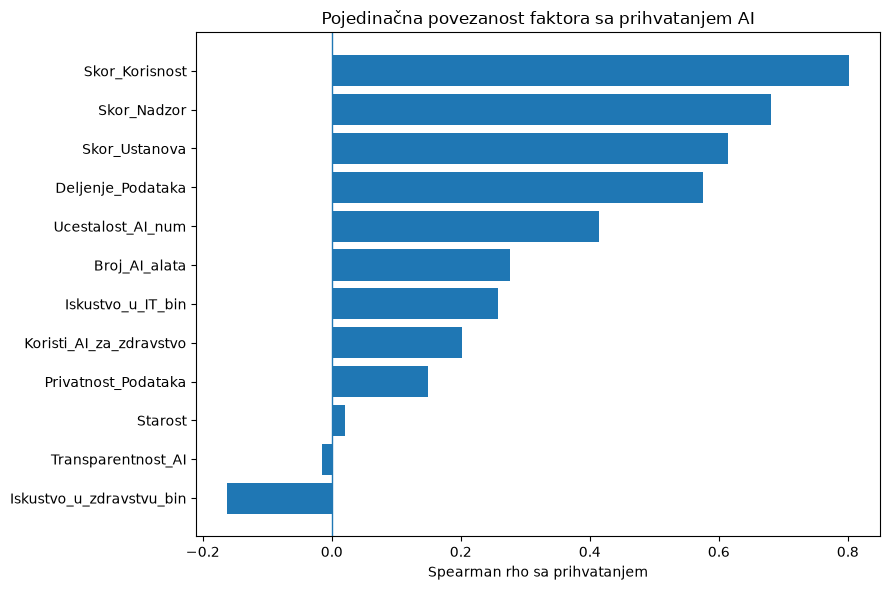

In [18]:
plot_corr=korelacije_prihvatanje.sort_values("Spearman rho"); plt.figure(figsize=(9,6)); plt.barh(plot_corr["Prediktor"],plot_corr["Spearman rho"]); plt.axvline(0,linewidth=1); plt.xlabel("Spearman rho sa prihvatanjem"); plt.title("Pojedinačna povezanost faktora sa prihvatanjem AI"); plt.tight_layout(); plt.show()

# FAZA VII Hijerarhijska višestruka regresija

In [19]:
kontrole=["Starost","Iskustvo_u_zdravstvu_bin","Iskustvo_u_IT_bin","Ucestalost_AI_num","Broj_AI_alata"]
teorijski_faktori=["Skor_Korisnost","Skor_Nadzor","Skor_Ustanova","Privatnost_Podataka","Transparentnost_AI"]
reg_cols=["Skor_Prihvatanje"]+kontrole+teorijski_faktori; reg_df=df[reg_cols].dropna().copy()

def standardized_ols(data,y_col,x_cols):
    z=data[[y_col]+x_cols].copy(); z=(z-z.mean())/z.std(ddof=0); X=sm.add_constant(z[x_cols]); return sm.OLS(z[y_col],X).fit(cov_type="HC3")

model1=standardized_ols(reg_df,"Skor_Prihvatanje",kontrole); model2=standardized_ols(reg_df,"Skor_Prihvatanje",kontrole+teorijski_faktori)
poredjenje_hijerarhijskih_modela=pd.DataFrame({"Model":["Model 1 — kontrole","Model 2 — kontrole + faktori"],"R²":[model1.rsquared,model2.rsquared],"Prilagođeni R²":[model1.rsquared_adj,model2.rsquared_adj],"N":[model1.nobs,model2.nobs],"ΔR²":[np.nan,model2.rsquared-model1.rsquared]}); display(poredjenje_hijerarhijskih_modela.round(4))

,Model,R²,Prilagođeni R²,N,ΔR²
0,Model 1 — kontrole,0.237,0.204,121.000,NaN
1,Model 2 — kontrole + faktori,0.678,0.648,121.000,0.441


In [20]:
def coef_table(model,name):
    ci=model.conf_int(); return pd.DataFrame({"Model":name,"Prediktor":model.params.index,"Standardizovani beta":model.params.values,"Standardna greška HC3":model.bse.values,"t vrednost":model.tvalues.values,"p vrednost":model.pvalues.values,"Donja granica 95% CI":ci[0].values,"Gornja granica 95% CI":ci[1].values})
koeficijenti_model1=coef_table(model1,"Model 1"); koeficijenti_model2=coef_table(model2,"Model 2"); display(koeficijenti_model1.round(4)); display(koeficijenti_model2.round(4))

,Model,Prediktor,Standardizovani beta,Standardna greška HC3,t vrednost,p vrednost,Donja granica 95% CI,Gornja granica 95% CI
0,Model 1,const,0.000,9.402,0.000,1.000,-18.428,18.428
1,Model 1,Starost,0.152,102.991,0.002,0.999,-201.706,202.010
2,Model 1,Iskustvo_u_zdravstvu_bin,-0.082,0.087,-0.946,0.344,-0.252,0.088
3,Model 1,Iskustvo_u_IT_bin,0.151,0.088,1.708,0.088,-0.022,0.324
4,Model 1,Ucestalost_AI_num,0.343,0.089,3.868,0.000,0.169,0.517
5,Model 1,Broj_AI_alata,0.098,0.082,1.194,0.233,-0.063,0.258


,Model,Prediktor,Standardizovani beta,Standardna greška HC3,t vrednost,p vrednost,Donja granica 95% CI,Gornja granica 95% CI
0,Model 2,const,0.000,4.718,0.000,1.000,-9.247,9.247
1,Model 2,Starost,0.045,51.681,0.001,0.999,-101.247,101.337
2,Model 2,Iskustvo_u_zdravstvu_bin,-0.030,0.060,-0.507,0.612,-0.147,0.086
3,Model 2,Iskustvo_u_IT_bin,0.089,0.066,1.351,0.177,-0.040,0.219
4,Model 2,Ucestalost_AI_num,0.155,0.060,2.595,0.009,0.038,0.273
5,Model 2,Broj_AI_alata,-0.038,0.071,-0.538,0.591,-0.178,0.101
6,Model 2,Skor_Korisnost,0.665,0.117,5.707,0.000,0.436,0.893
7,Model 2,Skor_Nadzor,0.067,0.093,0.722,0.470,-0.115,0.249
8,Model 2,Skor_Ustanova,0.034,0.093,0.361,0.718,-0.149,0.217
9,Model 2,Privatnost_Podataka,-0.022,0.074,-0.296,0.767,-0.168,0.124


## VIF

In [21]:
X_vif=reg_df[kontrole+teorijski_faktori].copy(); X_vif=(X_vif-X_vif.mean())/X_vif.std(ddof=0); X_vif=sm.add_constant(X_vif)
vif_tabela=pd.DataFrame({"Prediktor":X_vif.columns,"VIF":[variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]}); display(vif_tabela.round(3))

,Prediktor,VIF
0,const,1.000
1,Starost,1.073
2,Iskustvo_u_zdravstvu_bin,1.148
3,Iskustvo_u_IT_bin,1.203
4,Ucestalost_AI_num,1.328
5,Broj_AI_alata,1.484
6,Skor_Korisnost,4.009
7,Skor_Nadzor,2.802
8,Skor_Ustanova,2.315
9,Privatnost_Podataka,1.280


## Dijagnostika reziduala

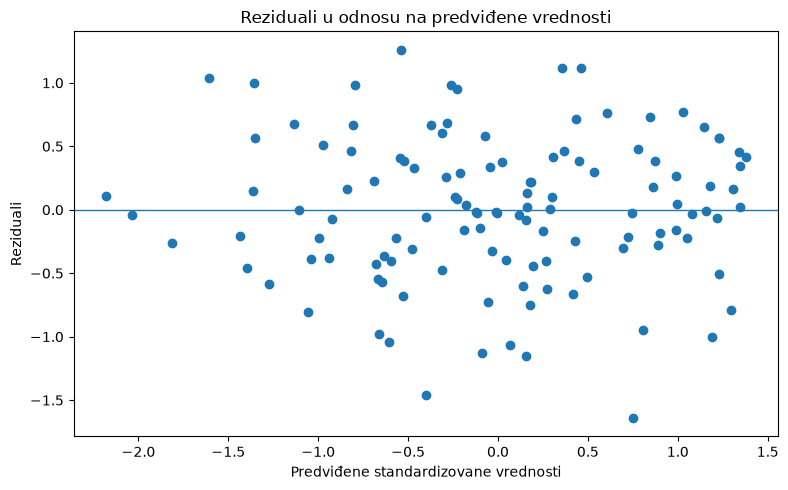

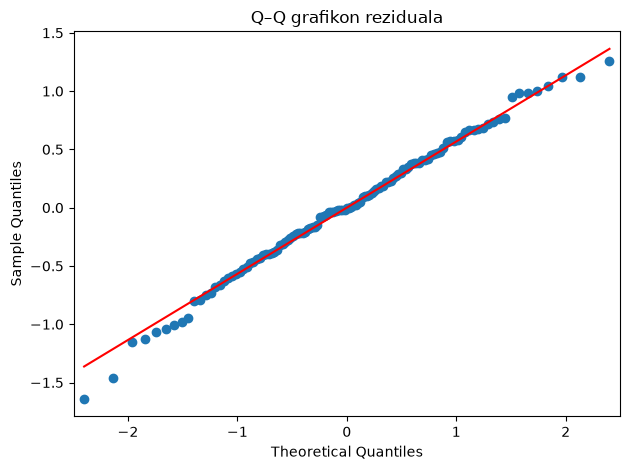

,Test,Statistika,p vrednost
0,Breusch–Pagan LM,11.934,0.289
1,Breusch–Pagan F,1.204,0.296


In [22]:
fitted=model2.fittedvalues; resid=model2.resid
plt.figure(figsize=(8,5)); plt.scatter(fitted,resid); plt.axhline(0,linewidth=1); plt.xlabel("Predviđene standardizovane vrednosti"); plt.ylabel("Reziduali"); plt.title("Reziduali u odnosu na predviđene vrednosti"); plt.tight_layout(); plt.show()
sm.qqplot(resid,line="s"); plt.title("Q–Q grafikon reziduala"); plt.tight_layout(); plt.show()
bp=het_breuschpagan(resid,model2.model.exog); bp_tabela=pd.DataFrame({"Test":["Breusch–Pagan LM","Breusch–Pagan F"],"Statistika":[bp[0],bp[2]],"p vrednost":[bp[1],bp[3]]}); display(bp_tabela.round(4))

# FAZA VIII Prediktivna regresija: Dummy, Ridge i Random Forest

In [23]:
prediktori_ml=kontrole+teorijski_faktori+["Deljenje_Podataka","Koristi_AI_za_zdravstvo"]

X_reg=df[prediktori_ml].copy(); y_reg=df["Skor_Prihvatanje"].copy()

preprocessor=ColumnTransformer([("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),prediktori_ml)],remainder="drop")

regresioni_modeli={
"Dummy regresija":Pipeline([("preprocessor",preprocessor),("model",DummyRegressor(strategy="mean"))]),
"Ridge regresija":Pipeline([("preprocessor",preprocessor),("model",Ridge(alpha=1.0))]),
"Random Forest regresija":Pipeline([("preprocessor",preprocessor),("model",RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=5,random_state=RANDOM_STATE,n_jobs=-1))])}
reg_cv=RepeatedKFold(n_splits=5,n_repeats=20,random_state=RANDOM_STATE); reg_scoring={"R2":"r2","MAE":"neg_mean_absolute_error","RMSE":"neg_root_mean_squared_error"}

def evaluate_reg(name,model):
    r=cross_validate(model,X_reg,y_reg,cv=reg_cv,scoring=reg_scoring,n_jobs=-1); return {"Model":name,"R² prosek":r["test_R2"].mean(),"R² SD":r["test_R2"].std(),"MAE prosek":-r["test_MAE"].mean(),"MAE SD":r["test_MAE"].std(),"RMSE prosek":-r["test_RMSE"].mean(),"RMSE SD":r["test_RMSE"].std()}
rezultati_prediktivne_regresije=pd.DataFrame([evaluate_reg(n,m) for n,m in regresioni_modeli.items()]).sort_values("R² prosek",ascending=False); display(rezultati_prediktivne_regresije.round(3))

,Model,R² prosek,R² SD,MAE prosek,MAE SD,RMSE prosek,RMSE SD
2,Random Forest regresija,0.572,0.129,0.512,0.079,0.649,0.085
0,Dummy regresija,-0.061,0.091,0.850,0.109,1.038,0.107
1,Ridge regresija,-84885.245,497033.238,14.054,58.972,66.903,288.528


Izabrani model: Random Forest regresija
Out-of-fold R²: 0.600
Out-of-fold MAE: 0.510
Out-of-fold RMSE: 0.653


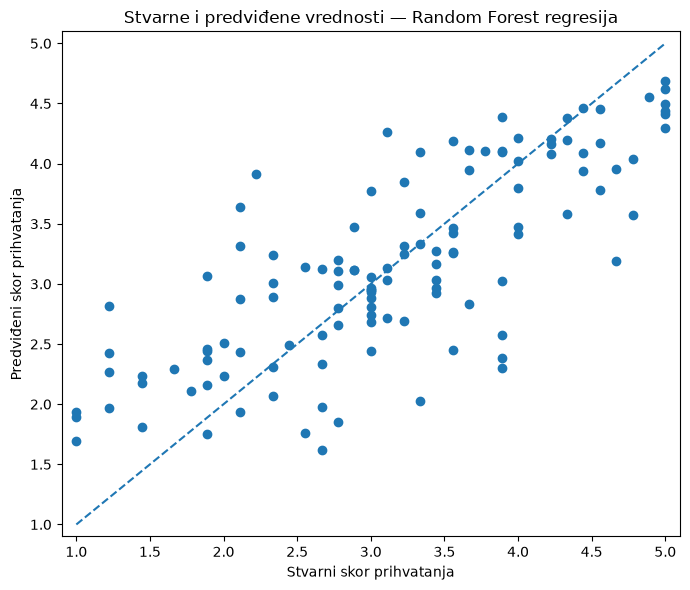

In [24]:
najbolji_reg_naziv=rezultati_prediktivne_regresije.iloc[0]["Model"]; najbolji_reg_model=regresioni_modeli[najbolji_reg_naziv]

oof_reg_pred=cross_val_predict(najbolji_reg_model,X_reg,y_reg,cv=RepeatedKFold(n_splits=5,n_repeats=1,random_state=RANDOM_STATE),n_jobs=-1)

print("Izabrani model:",najbolji_reg_naziv); print(f"Out-of-fold R²: {r2_score(y_reg,oof_reg_pred):.3f}"); print(f"Out-of-fold MAE: {mean_absolute_error(y_reg,oof_reg_pred):.3f}"); print(f"Out-of-fold RMSE: {mean_squared_error(y_reg,oof_reg_pred)**0.5:.3f}")

plt.figure(figsize=(7,6)); plt.scatter(y_reg,oof_reg_pred); plt.plot([1,5],[1,5],linestyle="--"); plt.xlim(.9,5.1); plt.ylim(.9,5.1); plt.xlabel("Stvarni skor prihvatanja"); plt.ylabel("Predviđeni skor prihvatanja"); plt.title(f"Stvarne i predviđene vrednosti — {najbolji_reg_naziv}"); plt.tight_layout(); plt.show()

# FAZA IX Klasifikacija visokog prihvatanja

In [25]:
df["Visoko_Prihvatanje"]=(df["Skor_Prihvatanje"]>=4.0).astype(int)
raspodela=df["Visoko_Prihvatanje"].value_counts().sort_index(); tabela_klasa=pd.DataFrame({"Broj":raspodela,"Procenat":raspodela/raspodela.sum()*100}); tabela_klasa.index=["Niže ili umereno prihvatanje","Visoko prihvatanje"]; display(tabela_klasa.round(1)); print(f"Udeo manje klase: {raspodela.min()/raspodela.sum():.3f}")

,Broj,Procenat
Niže ili umereno prihvatanje,93,76.900
Visoko prihvatanje,28,23.100


Udeo manje klase: 0.231


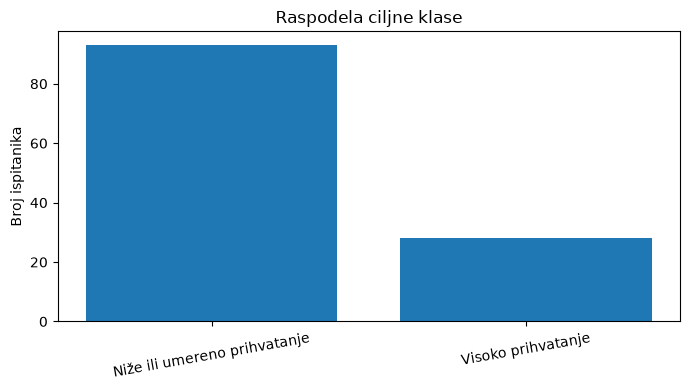

In [26]:
plt.figure(figsize=(7,4)); plt.bar(tabela_klasa.index,tabela_klasa["Broj"]); plt.ylabel("Broj ispitanika"); plt.title("Raspodela ciljne klase"); plt.xticks(rotation=10); plt.tight_layout(); plt.show()

# FAZA X Klasifikacioni modeli

In [27]:
X_cls=df[prediktori_ml].copy(); y_cls=df["Visoko_Prihvatanje"].copy()

klasifikacioni_modeli={
"Dummy klasifikator":Pipeline([("preprocessor",preprocessor),("model",DummyClassifier(strategy="prior"))]),
"Logistička regresija":Pipeline([("preprocessor",preprocessor),("model",LogisticRegression(max_iter=5000,class_weight="balanced",random_state=RANDOM_STATE))]),
"Random Forest klasifikacija":Pipeline([("preprocessor",preprocessor),("model",RandomForestClassifier(n_estimators=700,max_depth=4,min_samples_leaf=4,class_weight="balanced",random_state=RANDOM_STATE,n_jobs=-1))])}

cls_cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=20,random_state=RANDOM_STATE); cls_scoring={"ROC_AUC":"roc_auc","Balanced_accuracy":"balanced_accuracy","F1":"f1","Precision":"precision","Recall":"recall"}

def evaluate_cls(name,model):
    r=cross_validate(model,X_cls,y_cls,cv=cls_cv,scoring=cls_scoring,n_jobs=-1); return {"Model":name,"ROC-AUC prosek":r["test_ROC_AUC"].mean(),"ROC-AUC SD":r["test_ROC_AUC"].std(),"Balanced accuracy prosek":r["test_Balanced_accuracy"].mean(),"F1 prosek":r["test_F1"].mean(),"Precision prosek":r["test_Precision"].mean(),"Recall prosek":r["test_Recall"].mean()}
rezultati_klasifikacije=pd.DataFrame([evaluate_cls(n,m) for n,m in klasifikacioni_modeli.items()]).sort_values("ROC-AUC prosek",ascending=False); display(rezultati_klasifikacije.round(3))

,Model,ROC-AUC prosek,ROC-AUC SD,Balanced accuracy prosek,F1 prosek,Precision prosek,Recall prosek
2,Random Forest klasifikacija,0.946,0.047,0.842,0.735,0.705,0.795
1,Logistička regresija,0.918,0.057,0.848,0.725,0.657,0.844
0,Dummy klasifikator,0.500,0.000,0.500,0.000,0.000,0.000


Izabrani klasifikacioni model: Random Forest klasifikacija
                          precision    recall  f1-score   support

Niže/umereno prihvatanje       0.94      0.89      0.92        93
      Visoko prihvatanje       0.70      0.82      0.75        28

                accuracy                           0.88       121
               macro avg       0.82      0.86      0.84       121
            weighted avg       0.89      0.88      0.88       121

Out-of-fold ROC-AUC: 0.947


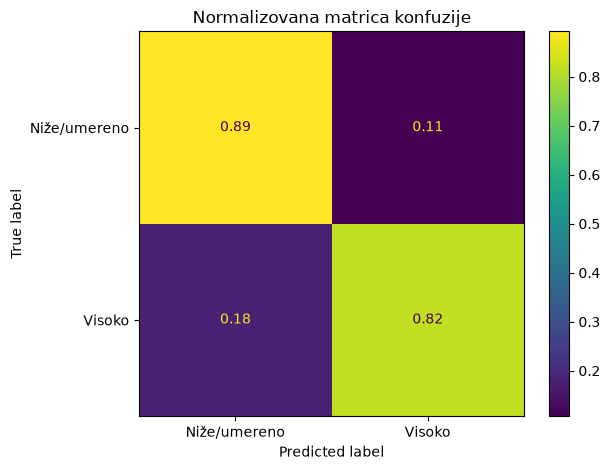

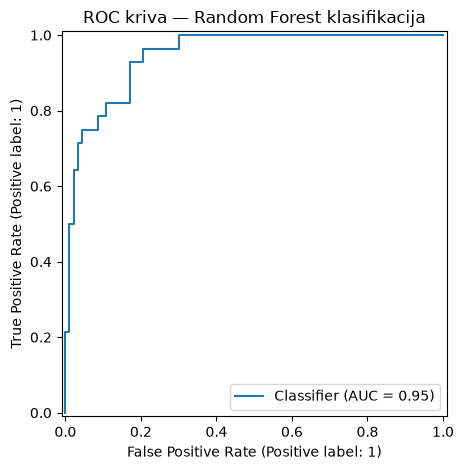

In [28]:
najbolji_cls_naziv=rezultati_klasifikacije.iloc[0]["Model"]; najbolji_cls_model=klasifikacioni_modeli[najbolji_cls_naziv]

single_cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=1,random_state=RANDOM_STATE)

oof_class_prob=cross_val_predict(najbolji_cls_model,X_cls,y_cls,cv=single_cv,method="predict_proba",n_jobs=-1)[:,1]; oof_class_pred=(oof_class_prob>=.5).astype(int)

print("Izabrani klasifikacioni model:",najbolji_cls_naziv); print(classification_report(y_cls,oof_class_pred,target_names=["Niže/umereno prihvatanje","Visoko prihvatanje"])); print(f"Out-of-fold ROC-AUC: {roc_auc_score(y_cls,oof_class_prob):.3f}")

ConfusionMatrixDisplay.from_predictions(y_cls,oof_class_pred,normalize="true",display_labels=["Niže/umereno","Visoko"]); plt.title("Normalizovana matrica konfuzije"); plt.tight_layout(); plt.show()

RocCurveDisplay.from_predictions(y_cls,oof_class_prob); plt.title(f"ROC kriva — {najbolji_cls_naziv}"); plt.tight_layout(); plt.show()

# FAZA XI Permutation importance Random Forest modela

,Prediktor,Prediktivna važnost,Standardna devijacija
5,Skor_Korisnost,0.096,0.022
7,Skor_Ustanova,0.016,0.009
3,Ucestalost_AI_num,0.011,0.005
11,Koristi_AI_za_zdravstvo,0.007,0.002
6,Skor_Nadzor,0.006,0.005
10,Deljenje_Podataka,0.005,0.004
0,Starost,0.003,0.001
4,Broj_AI_alata,0.001,0.001
2,Iskustvo_u_IT_bin,0.001,0.000
8,Privatnost_Podataka,0.001,0.000


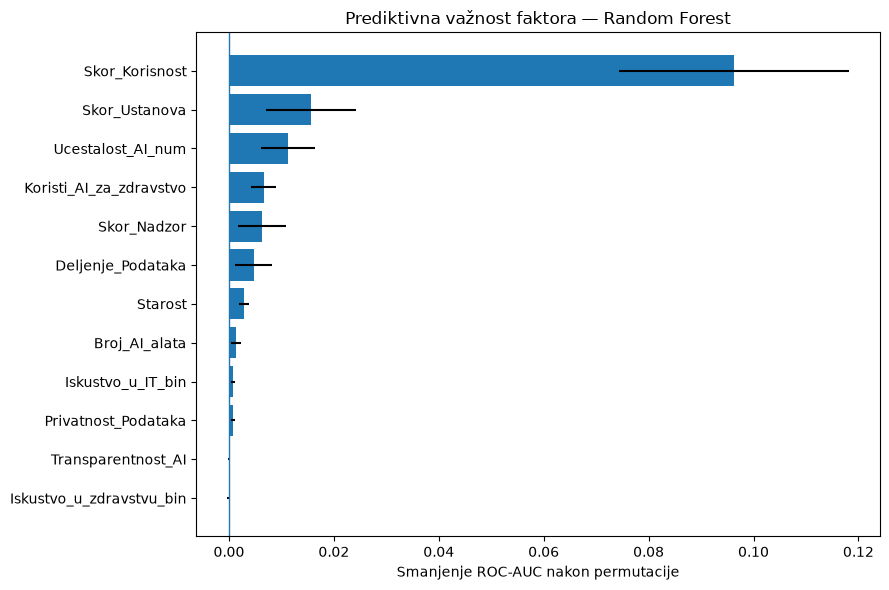

In [29]:
rf_cls=klasifikacioni_modeli["Random Forest klasifikacija"]; rf_cls.fit(X_cls,y_cls)

perm=permutation_importance(rf_cls,X_cls,y_cls,scoring="roc_auc",n_repeats=100,random_state=RANDOM_STATE,n_jobs=-1)

importance_df=pd.DataFrame({"Prediktor":prediktori_ml,"Prediktivna važnost":perm.importances_mean,"Standardna devijacija":perm.importances_std}).sort_values("Prediktivna važnost",ascending=False); display(importance_df.round(4))

plot_imp=importance_df.sort_values("Prediktivna važnost"); plt.figure(figsize=(9,6)); plt.barh(plot_imp["Prediktor"],plot_imp["Prediktivna važnost"],xerr=plot_imp["Standardna devijacija"]); plt.axvline(0,linewidth=1); plt.xlabel("Smanjenje ROC-AUC nakon permutacije"); plt.title("Prediktivna važnost faktora — Random Forest"); plt.tight_layout(); plt.show()

# FAZA XII Završna sinteza

In [30]:
ols_lookup=koeficijenti_model2.query("Prediktor != 'const'")[["Prediktor","Standardizovani beta","p vrednost"]].rename(columns={"p vrednost":"OLS p vrednost"})

sinteza=(korelacije_prihvatanje[["Prediktor","Spearman rho","p korigovano"]].merge(ols_lookup,on="Prediktor",how="left").merge(importance_df[["Prediktor","Prediktivna važnost"]],on="Prediktor",how="left")).sort_values(["Prediktivna važnost","Spearman rho"],ascending=False); display(sinteza.round(4))

,Prediktor,Spearman rho,p korigovano,Standardizovani beta,OLS p vrednost,Prediktivna važnost
0,Skor_Korisnost,0.802,0.000,0.665,0.000,0.096
2,Skor_Ustanova,0.615,0.000,0.034,0.718,0.016
9,Ucestalost_AI_num,0.414,0.000,0.155,0.009,0.011
11,Koristi_AI_za_zdravstvo,0.202,0.040,NaN,NaN,0.007
1,Skor_Nadzor,0.680,0.000,0.067,0.470,0.006
5,Deljenje_Podataka,0.576,0.000,NaN,NaN,0.005
6,Starost,0.020,0.868,0.045,0.999,0.003
10,Broj_AI_alata,0.276,0.004,-0.038,0.591,0.001
8,Iskustvo_u_IT_bin,0.259,0.007,0.089,0.177,0.001
3,Privatnost_Podataka,0.149,0.123,-0.022,0.767,0.001


# FAZA XIII Pregled hipoteza

In [31]:
def get_corr(pred):
    row=korelacije_prihvatanje.loc[korelacije_prihvatanje["Prediktor"]==pred]
    return (np.nan,np.nan) if row.empty else (row.iloc[0]["Spearman rho"],row.iloc[0]["p korigovano"])
hip=[]

for label,pred in [("Korisnost / prihvatanje","Skor_Korisnost"),("Privatnost / prihvatanje","Privatnost_Podataka"),("Transparentnost / prihvatanje","Transparentnost_AI"),("Ljudski nadzor / prihvatanje","Skor_Nadzor"),("Percepcija ustanove / prihvatanje","Skor_Ustanova")]:
    rho,p=get_corr(pred); hip.append([label,pred,rho,p,bool(rho>0 and p<.05)])
hipoteze_df=pd.DataFrame(hip,columns=["Odnos","Prediktor","Spearman rho","BH-korigovano p","Podržano bivarijantno"]); display(hipoteze_df.round(4))

,Odnos,Prediktor,Spearman rho,BH-korigovano p,Podržano bivarijantno
0,Korisnost / prihvatanje,Skor_Korisnost,0.802,0.000,True
1,Privatnost / prihvatanje,Privatnost_Podataka,0.149,0.123,False
2,Transparentnost / prihvatanje,Transparentnost_AI,-0.015,0.868,False
3,Ljudski nadzor / prihvatanje,Skor_Nadzor,0.680,0.000,True
4,Percepcija ustanove / prihvatanje,Skor_Ustanova,0.615,0.000,True
